In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast

In [2]:
def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path+f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path+f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

path = '../dataset/ptb_xl/'
sampling_rate=100

# load and convert annotation data
Y = pd.read_csv(path+'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)
# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train and test
test_fold = 10
# Train
X_train = X[np.where(Y.strat_fold != test_fold)]
y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass


In [3]:
def plot_ecg_12_leads(data_plot, data_label=['NORM']):
    plt.figure(figsize=(24,12))
    print(f"Class {data_label}")
    for i in range(12):
        plt.subplot(4,3,i+1)
        plt.plot(data_plot[:, i])
        plt.title(f"Lead {i+1}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

Class ['NORM']


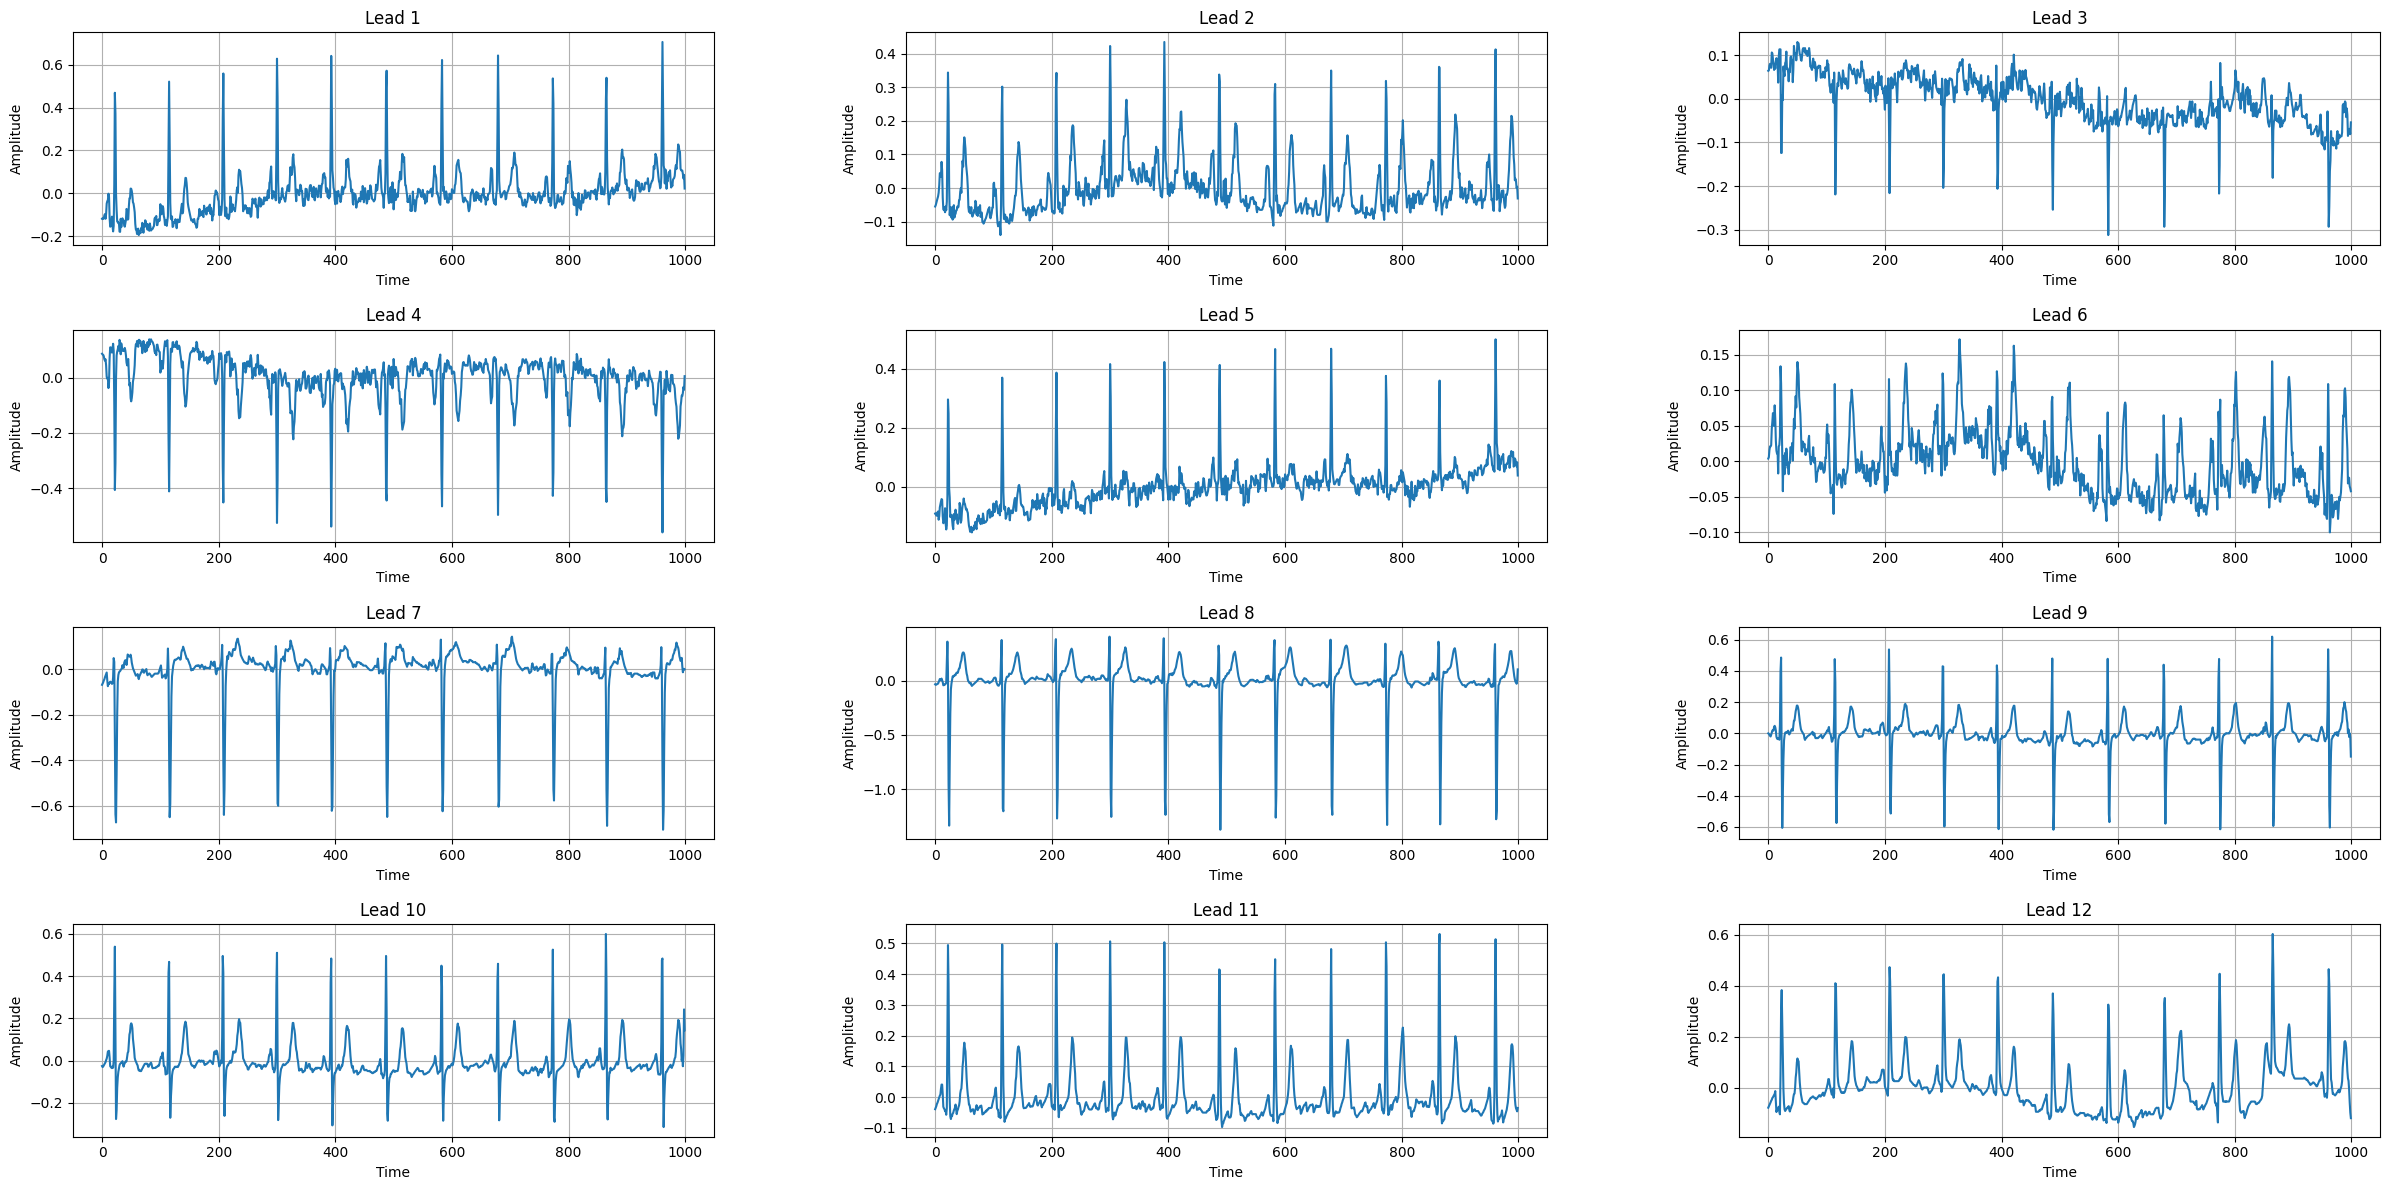

In [6]:
plot_ecg_12_leads(X_train[0, :])

In [19]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

In [38]:
def pan_tompkins(ecg, fs):
    """
    Pan-Tompkins R-peak detection algorithm.
    ecg: 1D numpy array of raw ECG signal
    fs: Sampling frequency in Hz
    """
    
    # 1. Bandpass Filter (5-15 Hz)
    nyq = 0.5 * fs
    low = 5 / nyq
    high = 15 / nyq
    b, a = signal.butter(1, [low, high], btype='band')
    ecg_filtered = signal.filtfilt(b, a, ecg)
    
    # 2. Differentiation
    diff = np.ediff1d(ecg_filtered)
    
    # 3. Squaring
    squared = diff ** 2
    
    # 4. Moving Window Integration (≈150ms window)
    window_size = int(0.150 * fs)
    mwa = np.convolve(squared, np.ones(window_size) / window_size, mode='same')
    
    # 5. Adaptive Thresholding
    threshold = np.mean(mwa) * 1.2  # tweak this as needed
    peaks, _ = signal.find_peaks(mwa, height=threshold, distance=int(0.3 * fs))  # refractory period ≈300ms

    # 6. Refine R-peaks: Find max in original ECG near each mwa peak
    r_peaks = []
    search_window = int(0.1 * fs)  # ±100ms window
    for peak in peaks:
        start = max(peak - search_window, 0)
        end = min(peak + search_window, len(ecg))
        r_peak = start + np.argmax(ecg[start:end])
        r_peaks.append(r_peak)

    return np.array(r_peaks), mwa, ecg_filtered

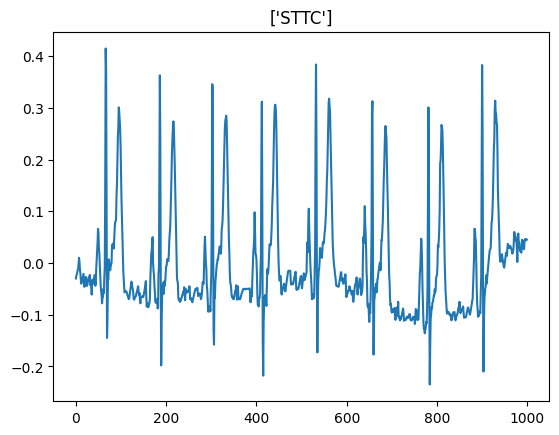

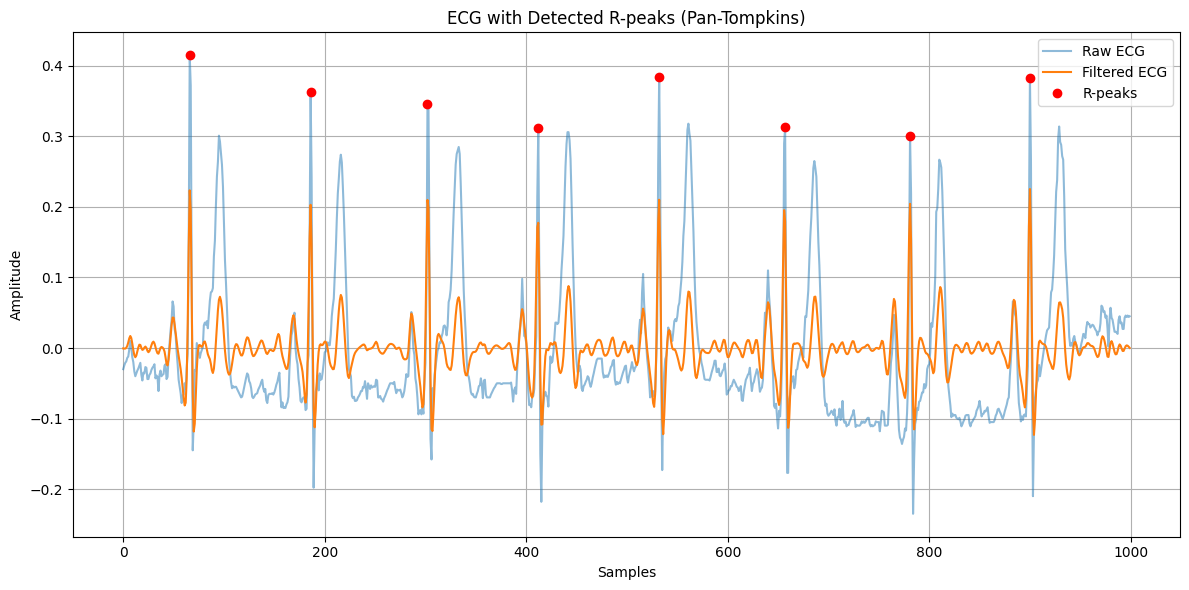

In [118]:

index = 54
ecg_, label_ = X_train[index, :, 1], y_train[index]
plt.plot(ecg_)
plt.title(label_)

# Detect R-peaks
sampling_rate = 100
r_peaks, mwa, ecg_filtered = pan_tompkins(ecg_, sampling_rate)

# Plot result
plt.figure(figsize=(12, 6))
plt.plot(ecg_, label='Raw ECG', alpha=0.5)
plt.plot(ecg_filtered, label='Filtered ECG')
plt.plot(r_peaks, ecg_[r_peaks], 'ro', label='R-peaks')
plt.title('ECG with Detected R-peaks (Pan-Tompkins)')
plt.legend()
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [61]:
def extract_beats_from_r(ecg, r_peaks, fs, post_ms=400):
    post_samples = int(125)
    #post_samples = int((post_ms / 1000.0) * fs)
    beats = []

    for r in r_peaks:
        end = r + post_samples
        if end <= len(ecg):
            beat = ecg[r:end]
            beats.append(beat)

    return np.array(beats)

In [78]:
beats = extract_beats_from_r(ecg_, r_peaks, 100)

# Plot first 3 extracted beats
#plt.figure(figsize=(12, 4))
#for i in range(min(3, len(beats))):
#    plt.plot(beats[i], label=f'Beat {i+1}')
#plt.title("Extracted ECG Beats (Aligned on R-Peak)")
#plt.xlabel("Samples")
#plt.ylabel("Amplitude")
#plt.legend()
#plt.grid(True)
#plt.tight_layout()
#plt.show()

In [65]:
def pad_beats_to_187(beats, target_length=187):
    """
    Pads each beat with zeros at the end to reach target length.
    Input: beats = list or array of shape (num_beats, current_length)
    Output: padded_beats = array of shape (num_beats, target_length)
    """
    padded_beats = []

    for beat in beats:
        pad_width = target_length - len(beat)
        if pad_width > 0:
            beat_padded = np.pad(beat, (0, pad_width), mode='constant', constant_values=0)
        else:
            beat_padded = beat[:target_length]  # truncate if longer
        padded_beats.append(beat_padded)

    return np.array(padded_beats)

In [71]:
def normalize_min_max(beats):
    """
    Normalize ECG beats to the range [0, 1] using Min-Max normalization.
    Input: beats = numpy array of shape (num_beats, 187)
    Output: normalized_beats = Min-Max normalized ECG beats
    """
    # Min and Max for each beat
    min_vals = np.min(beats, axis=1, keepdims=True)
    max_vals = np.max(beats, axis=1, keepdims=True)
    
    # Normalize each beat (avoid division by zero if max equals min)
    range_vals = max_vals - min_vals
    range_vals[range_vals == 0] = 1  # prevent division by zero
    
    normalized_beats = (beats - min_vals) / range_vals

    return normalized_beats

(13, 187)


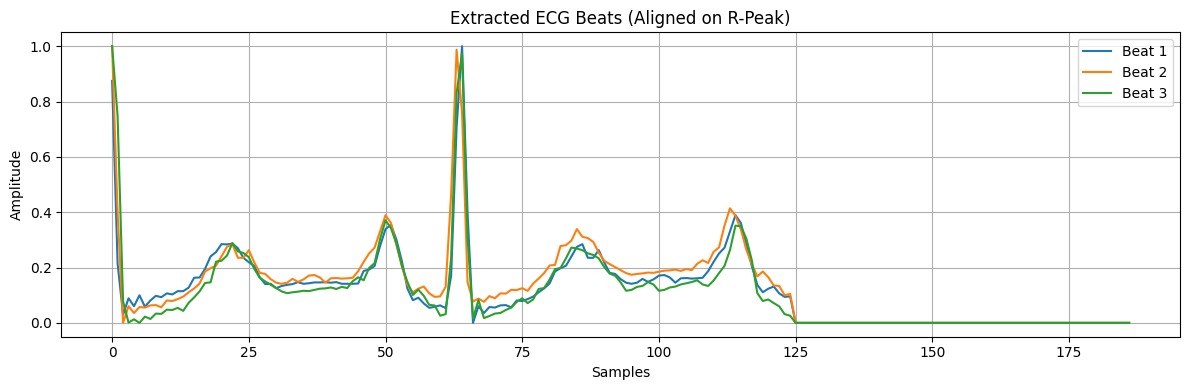

In [72]:
# Pad them all to 187
normalize_beats = normalize_min_max(beats)
padded_beats = pad_beats_to_187(normalize_beats)

print(padded_beats.shape)  # (10, 187)

# Plot first 3 extracted beats
plt.figure(figsize=(12, 4))
for i in range(min(3, len(padded_beats))):
    plt.plot(padded_beats[i], label=f'Beat {i+1}')
plt.title("Extracted ECG Beats (Aligned on R-Peak)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, SubsetRandomSampler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [74]:
class CNN(nn.Module):
    def __init__(self, input_size=187, num_classes=5):
        super(CNN, self).__init__()
        
        # Define convolutional layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=1, stride=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(32)
        
        self.conv4 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn4 = nn.BatchNorm1d(64)
        
        # Calculate the output size after convolutions and pooling
        dummy_input = torch.zeros(1, 1, input_size)  # Batch size = 1, channels = 1, input_size = input_size
        dummy_output = self._forward_convs(dummy_input)
        flattened_size = dummy_output.numel()  # Flattened size of the tensor after convolution and pooling
        self.fc = nn.Linear(flattened_size, num_classes)  # Correct size for the fully connected layer
        
    def _forward_convs(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.pool(x)
        
        return x

    def forward(self, x):
        x = self._forward_convs(x)  # Pass through the convolutional layers
        x = torch.flatten(x, 1)  # Flatten the tensor before feeding into the fully connected layer
        x = self.fc(x)  # Pass through the fully connected layer
        return x

In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
model.load_state_dict(torch.load('../train_models/models_save/CNN_model.pth'))
model.eval()

CNN(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (pool): MaxPool1d(kernel_size=1, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn4): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=768, out_features=5, bias=True)
)

In [80]:
print(padded_beats.shape)

(13, 187)


In [137]:
def plot_prediction(input,output):
    label_map = {0: 'N', 1: 'S', 2: 'P', 3: 'F', 4: 'U'}
    input_np = input.detach().squeeze().cpu().numpy()
    output_np = output.detach().squeeze().cpu().numpy()
    plt.figure(figsize=(24,12))
    for i in range(len(input_np)):
        plt.subplot(4,4,i+1)
        plt.plot(input_np[i])
        plt.title(f"Prediction {label_map[output_np[i]]}")
        plt.grid(True)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

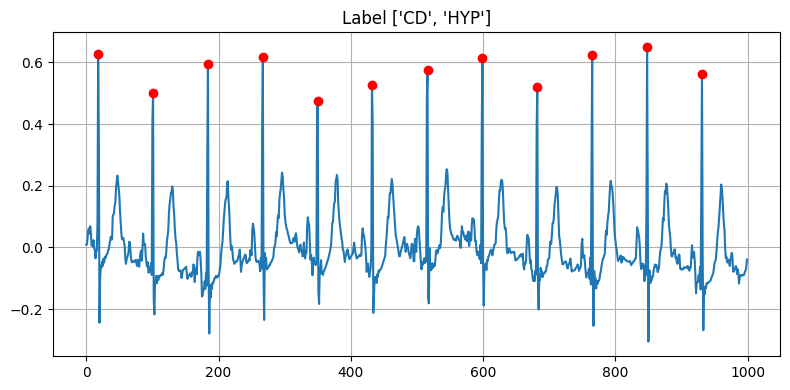

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


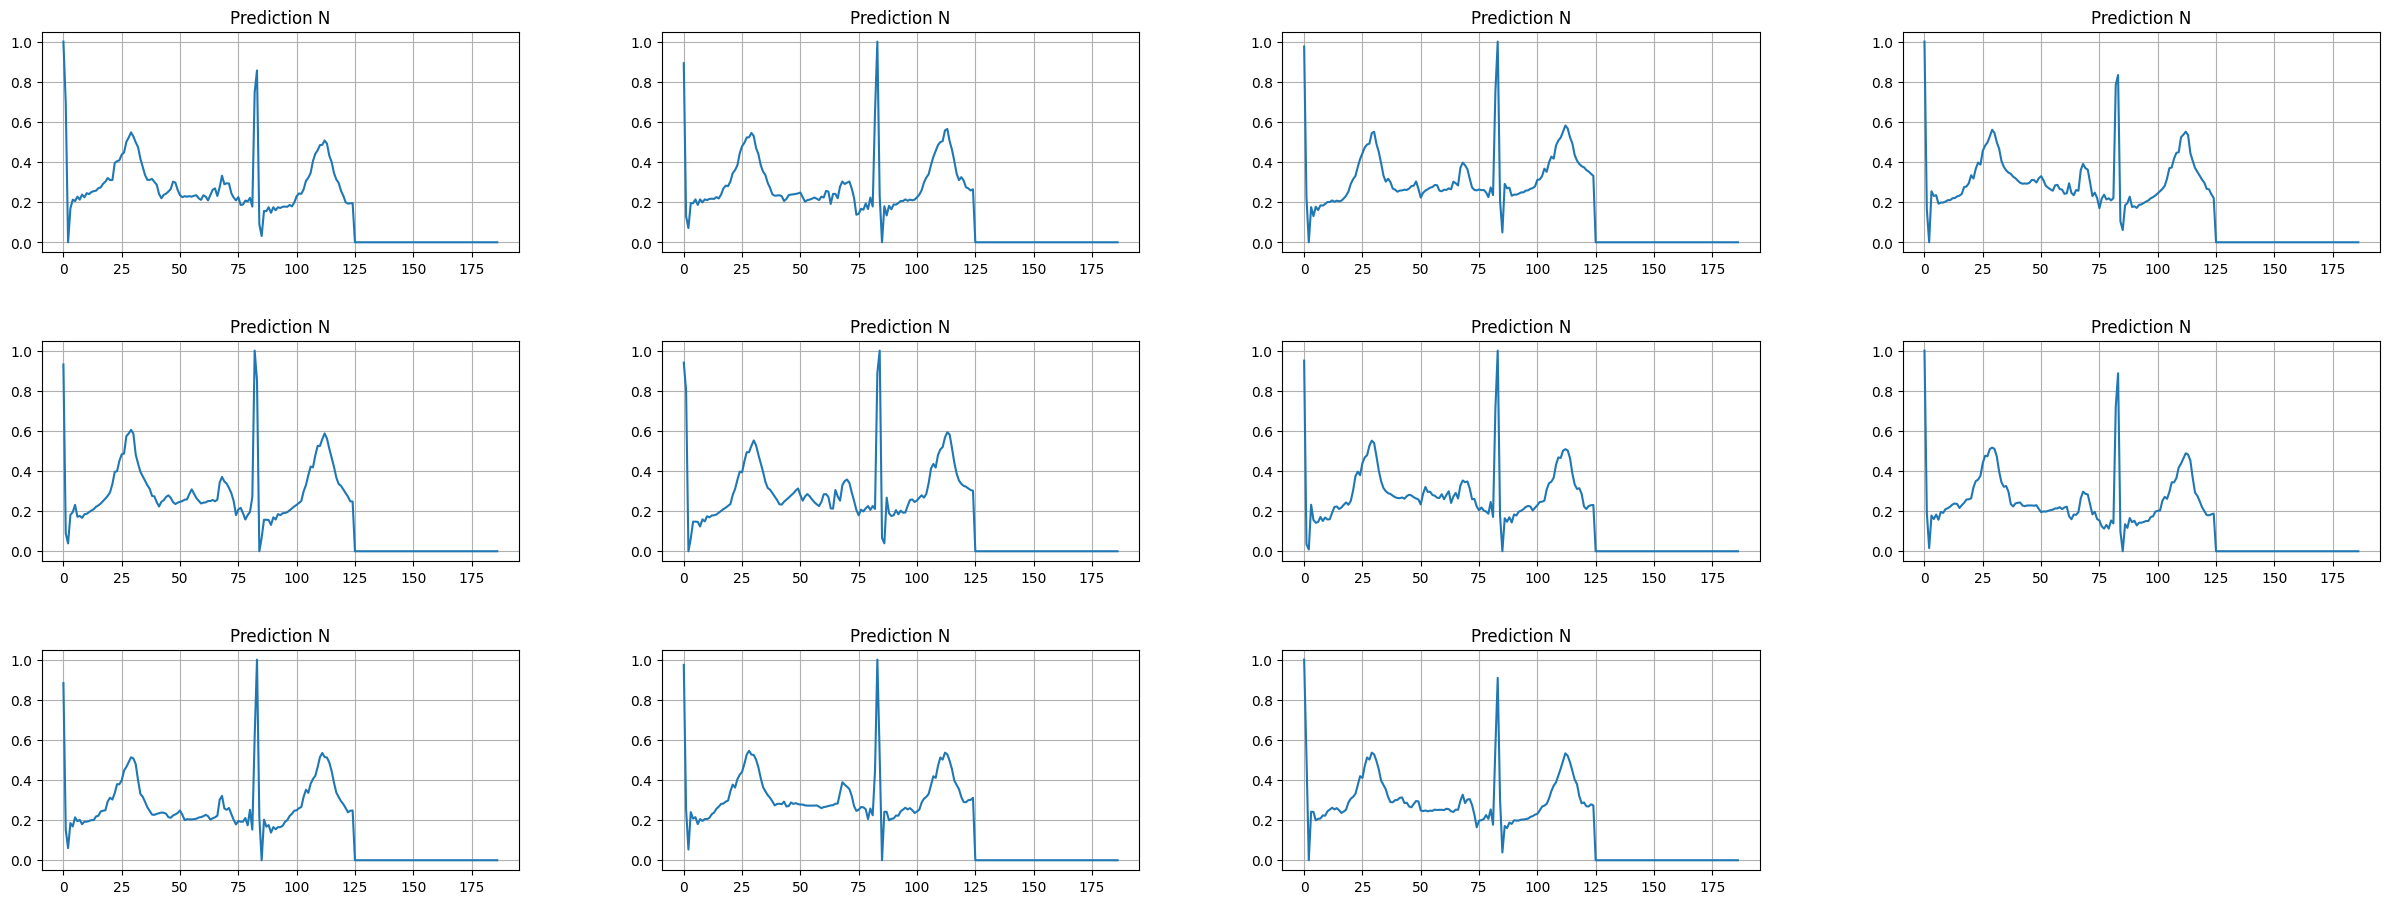

In [186]:
index = 12341
sampling_rate = 100
ecg_, label_ = X_train[index, :, 1], y_train[index]

r_peaks, mwa, ecg_filtered = pan_tompkins(ecg_, sampling_rate)
beats = extract_beats_from_r(ecg_, r_peaks, sampling_rate)
normalize_beats = normalize_min_max(beats)
padded_beats = pad_beats_to_187(normalize_beats)

plt.figure(figsize=(8,4))
plt.plot(ecg_)
plt.plot(r_peaks, ecg_[r_peaks], 'ro', label='R-peaks')
plt.title(f"Label {label_}")
plt.tight_layout()
plt.grid(True)
plt.show()

input_data = torch.from_numpy(padded_beats).float().unsqueeze(1).to(device)
with torch.no_grad():  # Turn off gradient tracking for inference
    output = model(input_data)
    labels = torch.argmax(output, dim=1)
print(labels)
plot_prediction(input_data, labels)

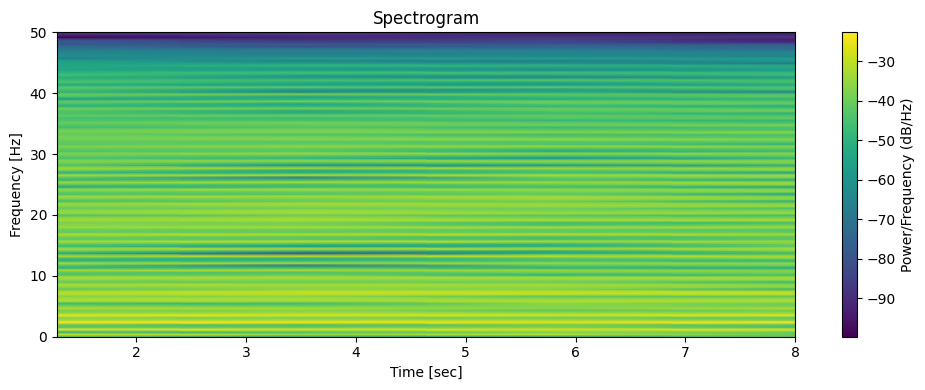

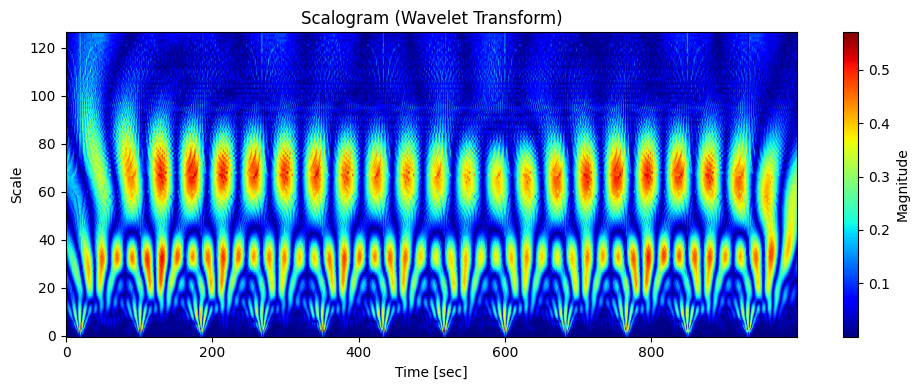

In [189]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pywt

# Compute spectrogram
frequencies, times, Sxx = signal.spectrogram(ecg_, sampling_rate)

# Plot
plt.figure(figsize=(10, 4))
plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx), shading='gouraud')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.title('Spectrogram')
plt.colorbar(label='Power/Frequency (dB/Hz)')
plt.tight_layout()
plt.show()

# Continuous Wavelet Transform (CWT)
wavelet = 'morl'  # Morlet is commonly used for ECG
scales = np.arange(1, 128)
coeffs, freqs = pywt.cwt(ecg_, scales, wavelet, sampling_period=1/sampling_rate)

# Plot scalogram
plt.figure(figsize=(10, 4))
plt.imshow(np.abs(coeffs), cmap='jet', aspect='auto', vmax=np.abs(coeffs).max())
plt.gca().invert_yaxis()
plt.colorbar(label='Magnitude')
plt.ylabel('Scale')
plt.xlabel('Time [sec]')
plt.title('Scalogram (Wavelet Transform)')
plt.tight_layout()
plt.show()